## Evaluation script

Author: Sahana Kowshik

Date: 04/14/2025

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import colormaps, cm, rc, rcParams
from matplotlib.container import BarContainer
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [16]:
# data = pd.read_csv("/projectnb/vkolagrp/projects/adrd_foundation_model/intermediate_data/nacc_processed_data/np_latest_visits.csv")

### 5 runs on baseline

In [58]:
def extract_naccid(row):
    naccid = row['problem']['NACCID']
    row['NACCID'] = naccid
    return row

def load_results(file_path):
    results = []

    with open(file_path,'r') as f:
        for line in f:
            results.append(json.loads(line))

    results_df = pd.DataFrame(results).explode(['generated_text','finish_reason'])
    results_df = results_df.apply(extract_naccid, axis=1)
    
    return results_df

In [59]:
def extract_final_answer(text):
    # match = re.search(r'<answer>\n(Answer: )([a-zA-Z])\n</answer>', text, re.DOTALL)
    match = re.search(r'<answer>.*\s*(Answer: )([a-zA-Z]).*\s*</answer>', text, re.DOTALL)
    # match = re.search(r'.*\s*(Answer: )([a-zA-Z]).*\s*', text, re.DOTALL)
    return match.group(2).strip().upper() if match else 'invalid'

def extract_answers(results_df):
    results_df['prediction'] = results_df['generated_text'].apply(extract_final_answer)
    results_df['ground_truth'] = [p['answer'] for p in results_df.problem]
    results_df['prediction'] = results_df['prediction'].replace({'N':'B','Y':'A'})
    results_df = results_df[results_df['prediction'] != 'invalid'].reset_index(drop=True)
    results_df.index = results_df.groupby('NACCID', sort=False).ngroup()
    return results_df

In [60]:
def modify(results_df, n):
    results_combined = results_df.copy()[['prediction','ground_truth']]
    results_combined.columns = ['prediction', 'ground_truth']
    results_combined['prediction'] = results_combined['prediction'].replace({'Y': 'A', 'N': 'B'})
    results_combined['ground_truth'] = results_combined['ground_truth']#.replace({'Yes': 'A', 'No': 'B'})
    results_combined['correctness'] = results_combined['prediction'] == results_combined['ground_truth']
    p = len(results_combined) // n
    # results_combined['run'] = list(range(1,p+1))*n
    results_combined = results_combined.reset_index(names=['problem']).reset_index(drop=True)
    return results_combined

In [61]:
def pass_at_k(df, n, k=1): 
    """ 
    :param n: total number of samples 
    :param c: number of correct samples 
    :param k: k in pass@$k$ """
    
    cs = df.groupby('problem').sum('correctness')
    vals = []
    for i, row in cs.iterrows():
        c = row['correctness']
        # print(n,c,k)
        if n - c < k: vals.append(1.0)
        else: vals.append(1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1)))
         
    # print(vals)
    return np.mean(vals)

In [62]:
def get_passat1(df):
    return df.groupby('problem').mean('correctness')[['correctness']].mean().iloc[0]

def get_consatk(df, n):
    return (
        df.groupby('problem')['prediction']
        .apply(lambda x: x.mode()[0]) == 
        df[['problem', 'ground_truth']].drop_duplicates('problem', keep='first')['ground_truth'].reset_index(drop=True)
    ).sum() / n

def combine_results(results_dict, n, k):
    final_dict = {'metric': ['pass@1', 'cons@k']}
    for key, v in results_dict.items():
        # final_dict[k] = [get_passat1(v), get_consat5(v)]
        # print(get_passat1(v), get_consat5(v))
        p = len(v) // n
        final_dict[key] = [pass_at_k(v, p, k), get_consatk(v, n)]
        
        # print(pass_at_k(v, 5, 1), get_consat5(v))
        # raise ValueError

    # Create a tidy DataFrame
    df = pd.DataFrame(final_dict)
    
    return df

In [63]:
def get_mean_length(df):
    lengths = []
    for i, row in df.iterrows():
        lengths.append(len(row['generated_text'].split(" ")))
        
    return sum(lengths) / len(lengths)

In [94]:
# Cognitive status
# qwen3b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-04T134012_1b22e7e417a94d74/qwen3b_adrd_cog_status_output.jsonl'
# qwen7b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-04T143137_cef7c4b897ef4879/qwen7b_adrd_cog_status_output.jsonl'
# llama8b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-04T162739_dfedefa6fa304b85/llama8b_adrd_cog_status_output.jsonl'
# qwen14b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-04T182106_5d9232d24f3840e8/qwen14b_adrd_cog_status_output.jsonl'
# deepseek_qwen7b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-04T215551_d31f5afb05184887/deepseek_qwen7b_adrd_cog_status_output.jsonl'
# qwen3b_rl_cog_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-04T140741_f69ea6deb56d4555/qwen3b_rl_cog_adrd_cog_status_output.jsonl'
# qwen3b_rl_lora_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-10T153433_d406fc9e0bcc4584/qwen3B_rl_lora_adrd_cog_status_output.jsonl'
# qwen3b_rl_lora_no_scale_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-11T114926_eaf66631a7b54c61/qwen3B_rl_lora_no_scale_adrd_cog_status_output.jsonl'
# qwen3b_rl_lora_half_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-10T165848_b9edf014cdc4418b/qwen3B_rl_lora_half_adrd_cog_status_output.jsonl'
# qwen7b_rl_lora_half_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-10T170115_473ef6a9fc58476d/qwen7B_rl_lora_half_adrd_cog_status_output.jsonl'
# qwen3b_rl_combined_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-10T172554_b1c91e98c7554366/qwen3B_rl_combined_adrd_cog_status_output.jsonl'
# n = 1000

# Cognitive status
# qwen3b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-04T134012_1b22e7e417a94d74/qwen3b_adrd_cog_status_output.jsonl'
qwen3b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-07T140716_5638ab7bf30348dc/qwen3b_summary_10_nocop_adrd_cog_status_summary_output.jsonl'
# qwen7b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-04T143137_cef7c4b897ef4879/qwen7b_adrd_cog_status_output.jsonl'
qwen7b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-07T142754_d312720a3a5546cf/qwen7b_summary_10_nocop_adrd_cog_status_summary_output.jsonl'
# qwen3b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-28T113939_56869e2fa3244199/qwen3b_drgrpo_adrd_cog_status_output.jsonl'
qwen3b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-02T174533_216ed996d0334af6/qwen3b_drgrpo_10_adrd_cog_status_summary_output.jsonl'
# qwen3_4b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-30T115311_4b06304f8e094283/qwen3_4b_adrd_cog_status_output.jsonl'
# qwen3b_drgrpo_summaries_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-02T153835_4c269e0dee06483d/qwen3b_drgrpo_summary_adrd_cog_status_summary_output.jsonl"
qwen3b_drgrpo_summaries_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-05T120511_35a285cb681242d5/qwen3b_drgrpo_summary_10_nocop_adrd_cog_status_summary_output.jsonl"
# qwen3b_drgrpo_train_json_test_summaries_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-05T130011_439ee106b2f0494e/qwen3b_drgrpo_train_json_test_summary_10_adrd_cog_status_summary_output.jsonl"
n = 1000

# # Neuropath
# qwen3b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-28T125650_bd6082ac569d4246/qwen3b_adrd_neuropath_output.jsonl'
# qwen7b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-28T132058_f1cf514216c744b3/qwen7b_adrd_neuropath_output.jsonl'
# # qwen3b_rl_combined_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-28T135401_c1b3ad3b879844f5/qwen3b_combined_adrd_neuropath_output.jsonl'
# qwen3b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-05T143454_8d5208c661114392/qwen3b_drgrpo_10_adrd_neuropath_summary_output.jsonl'
# qwen3b_drgrpo_summaries_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-05T141935_217d6e5b857740aa/qwen3b_drgrpo_summary_10_nocop_adrd_neuropath_summary_output.jsonl'
# n = 1000

In [95]:
# models_dict = {
#     'qwen3b': qwen3b_results_path,
#     # 'qwen7b': qwen7b_results_path,
#     # 'llama8b': llama8b_results_path,
#     # 'qwen14b': qwen14b_results_path,
#     # 'deepseek_qwen7b': deepseek_qwen7b_results_path,
#     # 'qwen3b_rl': qwen3b_rl_cog_results_path,
#     'qwen3b_rl_lora': qwen3b_rl_lora_results_path,
#     'qwen3b_rl_lora_no_scale': qwen3b_rl_lora_no_scale_results_path,
#     'qwen3b_rl_lora_half': qwen3b_rl_lora_half_results_path,
#     'qwen7b_rl_lora_half': qwen7b_rl_lora_half_results_path,
#     # 'qwen3b_rl_combined': qwen3b_rl_combined_results_path,
# }


In [98]:
# Cognitive status
models_dict = {
    'qwen3b': qwen3b_results_path,
    'qwen7b': qwen7b_results_path,
    'qwen3b_drgrpo_json': qwen3b_drgrpo_results_path,
    # 'qwen3_4b': qwen3_4b_results_path,
    'qwen3b_drgrpo_summaries': qwen3b_drgrpo_summaries_results_path,
    # 'qwen3b_drgrpo_train_json_test_summaries': qwen3b_drgrpo_train_json_test_summaries_results_path
}


In [99]:
# # Neuropath
# models_dict = {
#     'qwen3b': qwen3b_results_path,
#     # # 'qwen3b_rl_combined': qwen3b_rl_combined_results_path,\
#     'qwen7b': qwen7b_results_path,
#     'qwen3b_drgrpo_json': qwen3b_drgrpo_results_path,
#     'qwen3b_drgrpo_summaries': qwen3b_drgrpo_summaries_results_path
# }


In [100]:
model_dfs = {name: load_results(path) for name, path in models_dict.items()}
model_dfs = {name: extract_answers(df) for name, df in model_dfs.items()}
modified_models = {name: modify(df, n) for name, df in model_dfs.items()}

In [101]:
modified_models['qwen3b']

,problem,prediction,ground_truth,correctness
0,0,A,C,False
1,0,A,C,False
2,0,B,C,False
3,0,A,C,False
4,0,A,C,False
...,...,...,...,...
9403,999,B,A,False
9404,999,B,A,False
9405,999,B,A,False
9406,999,B,A,False


In [102]:
model_dfs['qwen3b']['prediction'].value_counts()

prediction
C    6132
B    2303
A     971
D       2
Name: count, dtype: int64

In [103]:
# model_dfs['qwen3b']['finish_reason'].value_counts()

### Evaluation

In [108]:
df = combine_results(modified_models, n, k=1)
df_long = df.melt(id_vars='metric', var_name='model', value_name='score')

In [109]:
# Step 1: Extract pass@1 values for sorting
pass_values = df_long[df_long["metric"] == "pass@1"].set_index("model")["score"]

# Step 2: Sort models based on pass@1
sorted_models = pass_values.sort_values().index.tolist()

# Step 3: Reorder the dataframe using concat instead of append
df_sorted = pd.concat([
    pd.concat([
        df_long[(df_long["model"] == model) & (df_long["metric"] == "pass@1")],
        df_long[(df_long["model"] == model) & (df_long["metric"] == "cons@k")]
    ])
    for model in sorted_models
], ignore_index=True)


In [110]:
# Step 1: Preserve model order from the original df
model_order = df_sorted['model'].drop_duplicates().tolist()

# Step 2: Pivot
df_pivot = df_sorted.pivot(index="model", columns="metric", values="score").loc[model_order].reset_index()

# Optional: Reorder columns
df_pivot = df_pivot[["model", "pass@1", "cons@k"]]
df_pivot

metric,model,pass@1,cons@k
0,qwen7b,0.765111,0.791
1,qwen3b,0.776333,0.796
2,qwen3b_drgrpo_json,0.860111,0.883
3,qwen3b_drgrpo_summaries,0.862556,0.864


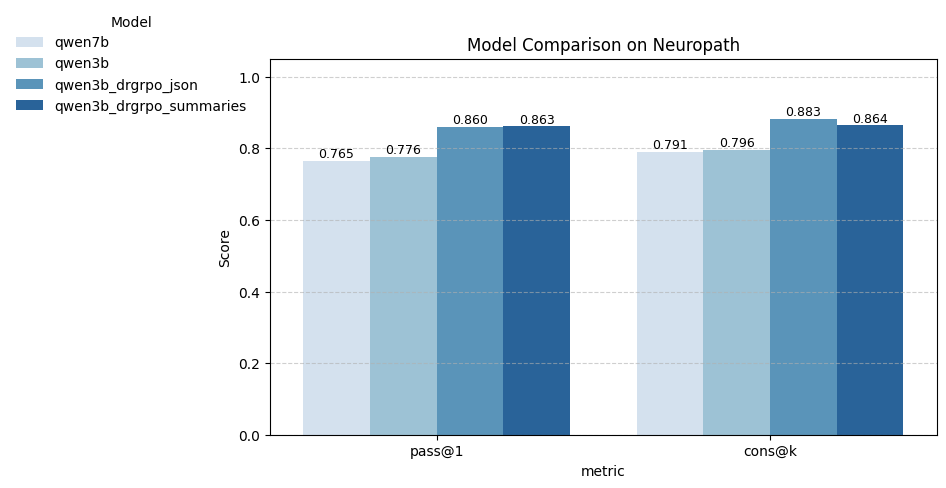

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_sorted, x='metric', y='score', hue='model', palette="Blues")

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=9)

plt.ylim(0, 1.05)
plt.ylabel("Score")
# plt.title("Model Comparison on Cognitive Status")
plt.title("Model Comparison on Neuropath")

# Move legend outside to the top left
plt.legend(title='Model', loc='upper left', bbox_to_anchor=(-0.4, 1.15), frameon=False)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [100]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(8, 5))
# ax = sns.barplot(data=df_sorted, x='metric', y='score', hue='model', palette="Blues")

# # Add value labels on top of each bar
# for container in ax.containers:
#     ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=9)

# plt.ylim(0, 1.05)
# plt.ylabel("Score")
# plt.title("Model Comparison on Cognitive Status")
# plt.legend(title='Model', loc="upper left")
# plt.grid(axis='y', linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()
